# MX

In [1]:
from PT3S import Mx

In [2]:
mx=Mx.Mx(r'..\testdata\M-1-0-1.MX1')

# with Pandas
MX-Channel TIMESTAMP (1st MX-Channel) used as DataFrame Index;
all other MX-Channels are DataFrame Columns

In [3]:
import pandas as pd

DataFrame

In [4]:
df=mx.getPdfFromMxsZipFile(mxsZipFile=r'..\testdata\M-1-0-1.ZIP')
type(df)

pandas.core.frame.DataFrame

Series

In [5]:
ts=df.iloc[1:-2,0]
type(ts)

pandas.core.series.Series

Timestamps

In [6]:
ts.index[0]

Timestamp('2017-06-18 23:00:00')

In [7]:
ts.index[-1]

Timestamp('2017-06-19 00:30:00')

DatetimeIndex

In [8]:
type(ts.index)

pandas.tseries.index.DatetimeIndex

Time Zone (tz_convert(None) will remove timezone after converting to UTC time)

In [9]:
print(ts.index.tz)

None


### Time Series Plot

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import dates

#### by MX-Channel-Idx

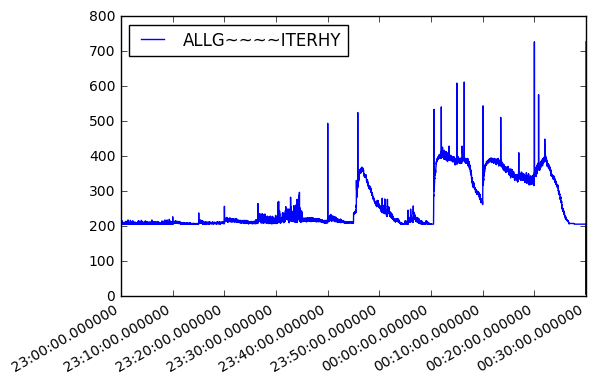

In [11]:
plt.figure()
df.iloc[:,17].plot()
plt.legend(loc='best')

#### by MX-Channel-Sir3sID

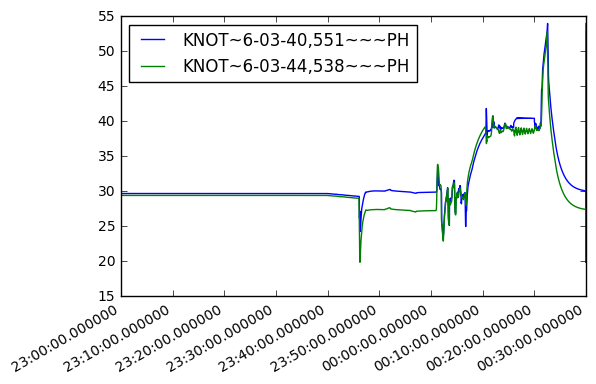

In [12]:
import re
regExpCompiled=re.compile(r'^KNOT~6-03-4\d+(\S+)~(\S*)~(\S*)~PH')
df_colsel=df.loc[:,sorted([column for column in df.columns if regExpCompiled.search(column) != None])]
df_colsel.plot()

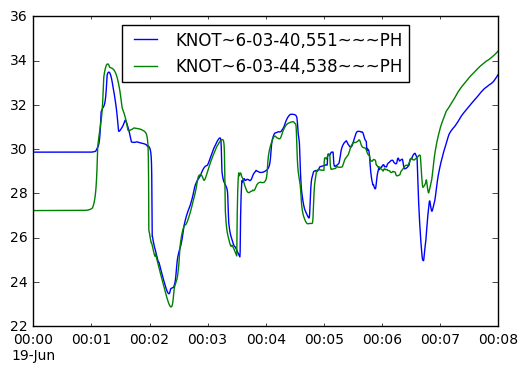

In [13]:
start=df_colsel.index[0].to_datetime()+pd.DateOffset(minutes=60)
end=start+pd.DateOffset(minutes=8)
df_colsel.between_time(start_time=start.time(), end_time=end.time()).plot()

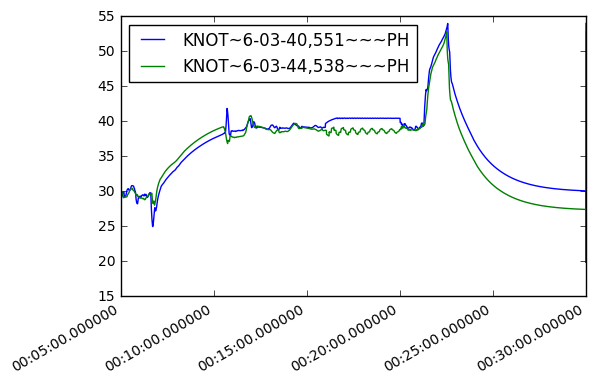

In [14]:
df_colsel[pd.datetime(2017,6,19,0,5):].plot()

#### SnapShotType

In [15]:
len(df)

21604

In [16]:
df.loc[:,[r'ALLG~~~~SNAPSHOTTYPE']].head(1)

,ALLG~~~~SNAPSHOTTYPE
2017-06-18 23:00:00,b'STAT'


In [17]:
df.loc[:,[r'ALLG~~~~SNAPSHOTTYPE']].tail(2)

,ALLG~~~~SNAPSHOTTYPE
2017-06-19 00:30:00,b'TMIN'
2017-06-19 00:30:00,b'TMAX'


In [18]:
len(df[df[r'ALLG~~~~SNAPSHOTTYPE'].isin([b'STAT',b'TMIN',b'TMAX'])])

3

In [19]:
df.loc[:,[r'ALLG~~~~SNAPSHOTTYPE',r'ALLG~~~~ITERHY']].groupby(r'ALLG~~~~SNAPSHOTTYPE').count()

,ALLG~~~~ITERHY
ALLG~~~~SNAPSHOTTYPE,
b'STAT',1
b'TIME',21601
b'TMAX',1
b'TMIN',1


In [20]:
df2=df[df[r'ALLG~~~~SNAPSHOTTYPE'].isin([b'TIME'])]

In [21]:
len(df2)

21601

In [22]:
df2.loc[:,'KNOT~6-03-44,538~~~PH'].head(4)

2017-06-18 23:00:00.000    29.404100
2017-06-18 23:00:00.250    29.404099
2017-06-18 23:00:00.500    29.404100
2017-06-18 23:00:00.750    29.404100
Name: KNOT~6-03-44,538~~~PH, dtype: float64

### Time Series Functions

In [23]:
ts=df2.loc[:,'KNOT~6-03-44,538~~~PH']

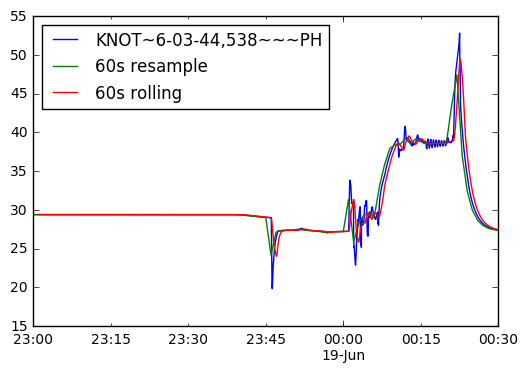

In [24]:
ts60=df2.loc[:,'KNOT~6-03-44,538~~~PH'].resample('60s').mean()
ts60.name='60s resample'
ts60r = ts.rolling(window=60*4).mean()
ts60r.name='60s rolling'
plt.figure()
ts.plot()
ts60.plot()
ts60r.plot()
plt.legend(loc='best')

In [25]:
df3=pd.DataFrame({ts60.name : ts60,ts.name : ts,ts60r.name : ts60r})
df3=df3.reindex_axis([ts.name,ts60.name,ts60r.name], axis=1)
df3.head()

,"KNOT~6-03-44,538~~~PH",60s resample,60s rolling
2017-06-18 23:00:00.000,29.404100,29.404088,NaN
2017-06-18 23:00:00.250,29.404099,NaN,NaN
2017-06-18 23:00:00.500,29.404100,NaN,NaN
2017-06-18 23:00:00.750,29.404100,NaN,NaN
2017-06-18 23:00:01.000,29.404099,NaN,NaN


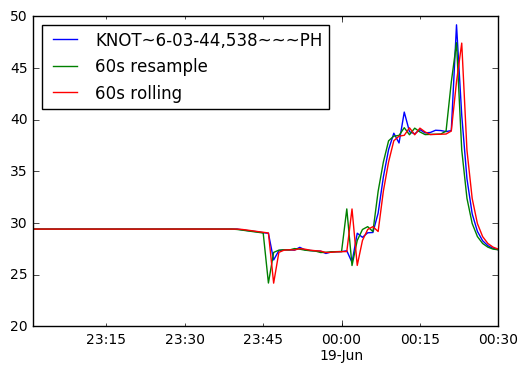

In [26]:
df3.dropna().plot()

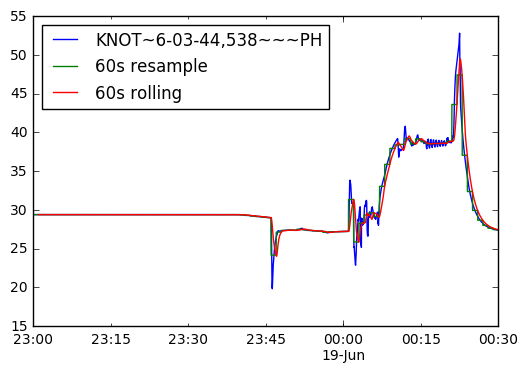

In [27]:
pPlot = df3.ffill().plot()
# type(pPlot) # matplotlib.axes._subplots.AxesSubplot

MATLAB, and pyplot, have the concept of the current figure and the current axes. All plotting commands
apply to the current axes.

The function gca() returns the current axes (a matplotlib.axes.Axes
instance), and gcf() returns the current figure (matplotlib.figure.Figure instance).

The subplot() command specifies numrows, numcols, num where num ranges from 1 to numrows*numcols.

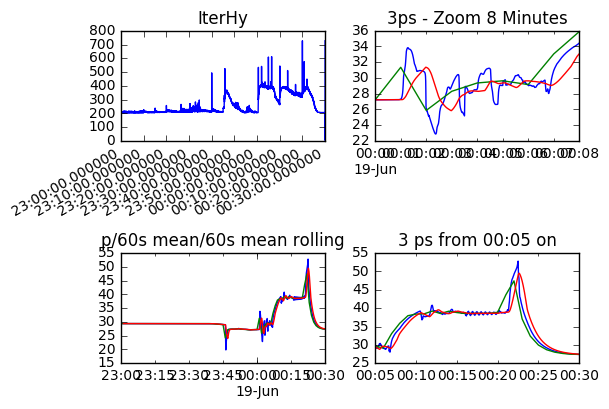

In [28]:
plt.figure(1)

plt.subplot(221)
plt.title('IterHy')
df.iloc[:,17].plot()

plt.subplot(223)
plt.title('p/60s mean/60s mean rolling')
ts.plot()
ts60.plot()
ts60r.plot()

plt.subplot(222)
plt.title('3ps - Zoom 8 Minutes')
ts.between_time(start_time=start.time(), end_time=end.time()).plot()
ts60.between_time(start_time=start.time(), end_time=end.time()).plot()
ts60r.between_time(start_time=start.time(), end_time=end.time()).plot()

plt.subplot(224)
plt.title('3 ps from 00:05 on')
ts[pd.datetime(2017,6,19,0,5):].plot()
ts60[pd.datetime(2017,6,19,0,5):].plot()
ts60r[pd.datetime(2017,6,19,0,5):].plot()
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0) #plt.subplots_adjust(top=0.92, ...)

plt.show()

In [29]:
#fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
#example_plot(ax1)
#def example_plot(ax, fontsize=12):
#    ax.plot(...)

"Hand-made" xaxis

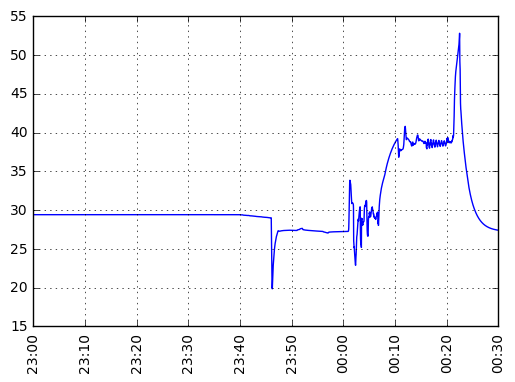

In [30]:
plt.close('all') 
plt.figure()
plt.subplot()
plt.gca().xaxis.set_major_locator(dates.MinuteLocator(interval=10))
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%H:%M'))
#plt.gcf().autofmt_xdate()
plt.plot(ts.index, ts)
labels=plt.gca().get_xticklabels()
plt.setp(labels,rotation=90)
plt.grid()
plt.show()